# Phase 2 — Cleaning

Some laps are slow for reasons that have nothing to do with tire wear. If they stay in, the
model learns them instead of learning degradation. Four rules remove them, and each removal
is counted separately so the total is explainable rather than opaque.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

pd.set_option("display.width", 130)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

from cleaning import add_clean_flags, clean
from data_loader import load_pit_stops
from dataset import build_lap_table

race, selected, laps = build_lap_table()
stops = load_pit_stops()
stops = stops[stops["raceId"] == race["raceId"]]

print(f"{race['name']} {race['year']}  |  {len(laps)} laps, {laps['driverId'].nunique()} drivers")

United States Grand Prix 2019  |  447 laps, 8 drivers


## The four rules

| Rule | Why |
| :-- | :-- |
| `pit_in` | The lap the car entered the pit lane, which contains the stop itself |
| `pit_out` | The lap after, begun at pit-lane speed on cold tires |
| `outlier` | Slower than 1.5x that driver's own median, as the brief specifies |
| `lap_one` | The opening lap, begun from a standstill on the grid |

The outlier test uses each driver's own median rather than the field median, so a slower car
is not penalised simply for being slower.

In [2]:
cleaned, report = clean(laps, stops)
report

,reason,description,laps_flagged
0,pit_in,Lap the car entered the pits,15
1,pit_out,"Lap after a pit stop, on cold tires",15
2,outlier,Slower than 1.5x that driver's median,0
3,lap_one,"Opening lap, standing start",8
4,TOTAL removed,unique laps (1 flagged by two rules at once),37
5,REMAINING,8.3% of 447 laps removed,410


## The outlier rule removes nothing, and that is the correct result

The brief's 1.5x rule exists to catch safety cars and off-track moments. This race has
neither, which is precisely why it was selected in Phase 1: its slowest field-median lap is
1.073x the race median, the lowest of the 2019 season.

The threshold sits around 151 seconds. The slowest lap in the data outside the pits is far
below it. A count of zero here is evidence the race selection worked, not evidence the rule
was applied wrongly.

In [3]:
flagged = add_clean_flags(laps, stops)
green = flagged[~flagged["is_pit_in"] & ~flagged["is_pit_out"] & ~flagged["is_lap_one"]]

print(f"outlier threshold, by driver : {1.5 * flagged['driver_median'].min():.1f}s to "
      f"{1.5 * flagged['driver_median'].max():.1f}s")
print(f"slowest non-pit, non-lap-1 lap: {green['seconds'].max():.3f}s")
print(f"margin to the nearest threshold: {1.5 * flagged['driver_median'].min() - green['seconds'].max():.1f}s")

outlier threshold, by driver : 150.3s to 154.2s
slowest non-pit, non-lap-1 lap: 104.574s
margin to the nearest threshold: 45.7s


## Why lap 1 is removed

Lap 1 begins from a standstill on the grid and includes the first-corner scramble, so it is
several seconds slower than a green-flag lap. That is a starting-procedure effect, not a tire
effect.

It matters more than a generic outlier would, because **lap 1 is always run on brand new
tires**. Keeping it would place a very slow lap at a tire age of zero for every driver, and
teach the model that fresh tires are slow. That is the opposite of the effect being measured.

The brief does not call for this removal. It is an addition, reported here rather than made
silently.

In [4]:
lap_one = flagged[flagged["is_lap_one"]]
print(f"lap 1 median      {lap_one['seconds'].median():.3f}s")
print(f"all other laps    {green['seconds'].median():.3f}s")
print(f"lap 1 penalty     {lap_one['seconds'].median() - green['seconds'].median():+.3f}s\n")

_, report_keep = clean(laps, stops, drop_lap_one=False)
kept, _ = clean(laps, stops, drop_lap_one=False)
print(f"slowest lap if lap 1 kept    {kept['seconds'].max():.3f}s   (sd {kept['seconds'].std():.3f}s)")
print(f"slowest lap if lap 1 removed {cleaned['seconds'].max():.3f}s   (sd {cleaned['seconds'].std():.3f}s)")

lap 1 median      105.290s
all other laps    100.689s
lap 1 penalty     +4.601s

slowest lap if lap 1 kept    110.500s   (sd 1.620s)
slowest lap if lap 1 removed 104.574s   (sd 1.495s)


## Before and after

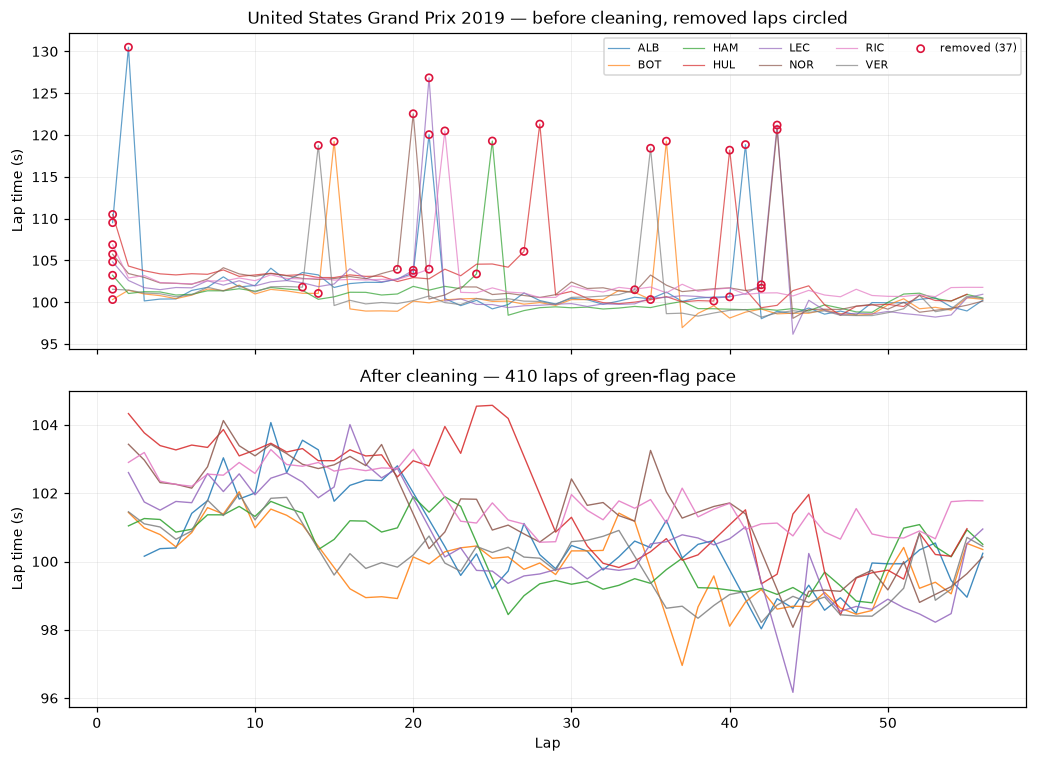

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9.5, 7), sharex=True)

removed = flagged[flagged["is_pit_in"] | flagged["is_pit_out"] | flagged["is_lap_one"]]

for code, grp in flagged.groupby("code"):
    ax1.plot(grp["lap"], grp["seconds"], lw=0.8, alpha=0.7, label=code)
ax1.scatter(removed["lap"], removed["seconds"], s=22, facecolor="none",
            edgecolor="crimson", lw=1.1, zorder=5, label=f"removed ({len(removed)})")
ax1.set_ylabel("Lap time (s)")
ax1.set_title(f"{race['name']} {race['year']} — before cleaning, removed laps circled")
ax1.legend(ncol=5, fontsize=7)
ax1.grid(alpha=0.25, lw=0.5)

for code, grp in cleaned.groupby("code"):
    ax2.plot(grp["lap"], grp["seconds"], lw=0.9, alpha=0.85, label=code)
ax2.set_xlabel("Lap")
ax2.set_ylabel("Lap time (s)")
ax2.set_title(f"After cleaning — {len(cleaned)} laps of green-flag pace")
ax2.grid(alpha=0.25, lw=0.5)

fig.tight_layout()
fig.savefig(ROOT / "figures" / "02_cleaning_before_after.png", dpi=150, bbox_inches="tight")
plt.show()

The lower panel is what the models will see. The sawtooth is gone, and what remains is a
gentle downward drift with a repeating rise inside each stint. That drift is fuel burn and
those rises are tire wear. Phase 3 builds features to separate the two.

In [6]:
report.to_csv(ROOT / "results" / "cleaning_report.csv", index=False)
cleaned.to_csv(ROOT / "results" / "laps_cleaned.csv", index=False)

print(f"{len(laps)} laps in, {len(cleaned)} out, {len(laps) - len(cleaned)} removed "
      f"({(len(laps) - len(cleaned)) / len(laps):.1%})")
print(f"laps per driver: min {cleaned.groupby('code').size().min()}, "
      f"max {cleaned.groupby('code').size().max()}")
cleaned.groupby("code").size().rename("laps").to_frame().T

447 laps in, 410 out, 37 removed (8.3%)
laps per driver: min 50, max 53


code,ALB,BOT,HAM,HUL,LEC,NOR,RIC,VER
laps,50,51,53,50,51,51,53,51


---

**Phase 2 complete.** 37 of 447 laps removed, 8.3%, each attributable to a named rule.
Phase 3 derives tire age, stint number and a fuel proxy from what remains.